In [5]:
pip install scikit-learn

   ---------------------------------------- 0.0/8.0 MB ? eta -:--:--
   --- ------------------------------------ 0.8/8.0 MB 5.3 MB/s eta 0:00:02
   ------- -------------------------------- 1.6/8.0 MB 4.2 MB/s eta 0:00:02
   ---------- ----------------------------- 2.1/8.0 MB 3.8 MB/s eta 0:00:02
   ------------------- -------------------- 3.9/8.0 MB 5.0 MB/s eta 0:00:01
   -------------------------- ------------- 5.2/8.0 MB 5.3 MB/s eta 0:00:01
   ------------------------------ --------- 6.0/8.0 MB 5.1 MB/s eta 0:00:01
   ---------------------------------------  7.9/8.0 MB 5.5 MB/s eta 0:00:01
   ---------------------------------------- 8.0/8.0 MB 5.0 MB/s  0:00:01
   ---------------------------------------- 0.0/36.3 MB ? eta -:--:--
   - -------------------------------------- 1.3/36.3 MB 5.9 MB/s eta 0:00:06
   --- ------------------------------------ 3.1/36.3 MB 7.4 MB/s eta 0:00:05
   ---- ----------------------------------- 4.2/36.3 MB 6.4 MB/s eta 0:00:05
   ----- ----------------

In [21]:
from sklearn.datasets import fetch_california_housing

data=fetch_california_housing()

x=data.data
y=data.target




In [22]:
data

{'data': array([[   8.3252    ,   41.        ,    6.98412698, ...,    2.55555556,
           37.88      , -122.23      ],
        [   8.3014    ,   21.        ,    6.23813708, ...,    2.10984183,
           37.86      , -122.22      ],
        [   7.2574    ,   52.        ,    8.28813559, ...,    2.80225989,
           37.85      , -122.24      ],
        ...,
        [   1.7       ,   17.        ,    5.20554273, ...,    2.3256351 ,
           39.43      , -121.22      ],
        [   1.8672    ,   18.        ,    5.32951289, ...,    2.12320917,
           39.43      , -121.32      ],
        [   2.3886    ,   16.        ,    5.25471698, ...,    2.61698113,
           39.37      , -121.24      ]], shape=(20640, 8)),
 'target': array([4.526, 3.585, 3.521, ..., 0.923, 0.847, 0.894], shape=(20640,)),
 'frame': None,
 'target_names': ['MedHouseVal'],
 'feature_names': ['MedInc',
  'HouseAge',
  'AveRooms',
  'AveBedrms',
  'Population',
  'AveOccup',
  'Latitude',
  'Longitude'],
 'DESCR': 

In [24]:
import pandas as pd
df=pd.DataFrame(x)
df.columns=['MedInc','HouseAge',
  'AveRooms',
  'AveBedrms',
  'Population',
  'AveOccup',
  'Latitude',
  'Longitude']

In [25]:
df

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25
...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32


In [32]:
# train test split
from sklearn.model_selection import train_test_split

In [33]:
X_train,X_test , Y_train ,Y_test=train_test_split(x,y,test_size=0.30,random_state=42)

In [27]:
# after loading the dataset  and splitting it second step is to standardize the dataset , to make it more efficient prediction system as it contains so many features on different scales ,during training model will learn less from those parameters which have small scales takes so much time during the training  and gives us a bad predicting model.

# so we choose standardization which makes all the features to similar scales and model learns from all features equally and it makes training faster and efficient ,with a smooth gradient descent.

In [36]:
from sklearn.preprocessing import StandardScaler


In [37]:
scaler=StandardScaler()

In [39]:
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

In [47]:
from sklearn.linear_model import LinearRegression
model=LinearRegression()


In [54]:
# 3. cross validation
from sklearn.model_selection import cross_val_score
import numpy as np
cross_val_score=cross_val_score(model,X_train,Y_train,scoring='r2',cv=50)
r2_score=np.mean(cross_val_score)

np.float64(0.6060862622641913)

In [55]:
model.fit(X_train,Y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


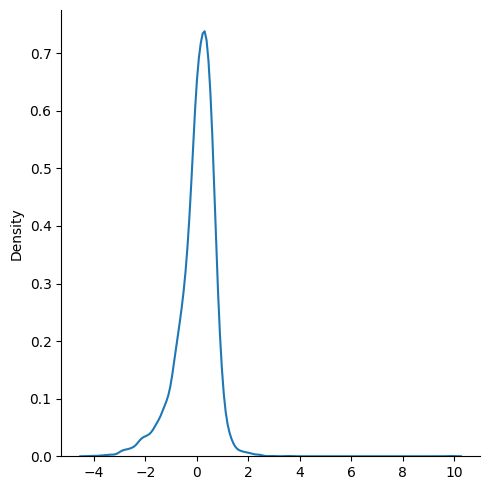

In [62]:
import seaborn as sns
sns.displot(model.predict(X_train)-Y_train,kind="kde")

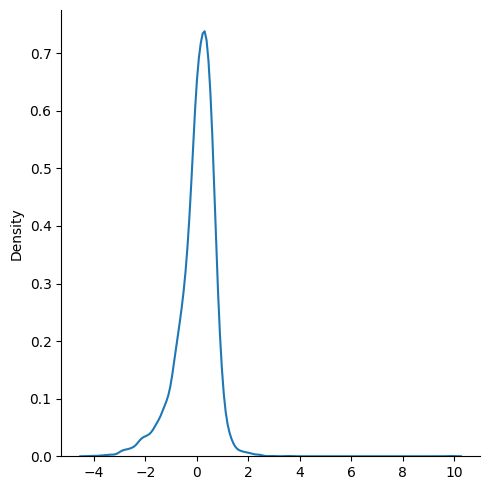

In [64]:
sns.displot(model.predict(X_test)-Y_test,kind="kde")